## TASK #2: IMPORT LIBRARIES AND DATASET

![Sales Department Png](Sales_Department_Png/1.png)

![Sales Department Png](Sales_Department_Png/2.png)

![Sales Department Png](Sales_Department_Png/3.png)

![Sales Department Png](Sales_Department_Png/4.png)

![Sales Department Png](Sales_Department_Png/5.png)

![Sales Department Png](Sales_Department_Png/6.png)

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from  prophet.plot import plot_plotly, plot_components_plotly 
from prophet import Prophet

reading the sales dataset

In [120]:
sales_df = pd.read_csv("train.txt")

/var/folders/8j/89s2c2p95jbdkvqchwlmb2rr0000gn/T/ipykernel_97077/1210347703.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  sales_df = pd.read_csv("train.txt")


* almost a million observation
* 1115 unique stores
* Note that sales is the target variable (that's what we are trying to predict)

* Id: transaction ID (combination of Store and date)
* Store: unique store Id
* Sales: sales/day, this is the target variable
* Customers: number of customers on a given day
* Open: Boolean to say whether a store is open or closed (0 = closed, 1 = open)
* Promo: describes if store is running a promo on that day or not
* StateHoliday: indicate which state holiday (a = public holiday, b = Easter holiday, c = Christmas, 0 = None)
* SchoolHoliday: indicates if the (Store, Date) was affected by the closure of public schools
* Data Source: https://www.kaggle.com/c/rossmann-store-sales/data

In [121]:
sales_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [122]:
sales_df.tail()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1
1017208,1115,2,2013-01-01,0,0,0,0,a,1


* 9 columns in total
* 8 features, each contains 1017209 data points
* 1 target variable (sales)

In [123]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [124]:
sales_df.describe()
# Average sales amount per day = 5773 Euros, minimum sales per day = 0, maximum sales per day = 41551
# Average number of customers = 633, minimum number of customers = 0, maximum number of customers = 7388

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


## TASK #2.2: IMPORT STORE INFORMATION DATA

* StoreType: categorical variable to indicate type of store (a, b, c, d)
* Assortment: describes an assortment level: a = basic, b = extra, c = extended
* CompetitionDistance (meters): distance to closest competitor store
* CompetitionOpenSince [Month/Year]: provides an estimate of the date when competition was open
* Promo2: Promo2 is a continuing and consecutive promotion for some stores (0 = store is not participating, 1 = store is participating)
* Promo2Since [Year/Week]: date when the store started participating in Promo2
* PromoInterval: describes the consecutive intervals Promo2 is started, naming the months the promotion is started anew. E.g. "Feb,May,Aug,Nov" means each round starts in February, May, August, November of any given year for that store

In [125]:
store_df = pd.read_csv('store.txt')

In [126]:
store_df.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [127]:
store_df.tail()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN
1114,1115,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec"


* Let's do the same for the store_info_df data
* Note that the previous dataframe includes the transactions recorded per day (in millions)
* This dataframe only includes information about the unique 1115 stores that are part of this study

In [128]:
store_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


* on average, the competition distance is 5404 meters away (5.4 kms)

In [129]:
store_df.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


## TASK #3: EXPLORE DATASET

#### TASK #3.1: EXPLORE SALES TRAINING DATA

Let's see if we have any missing data

<Axes: >

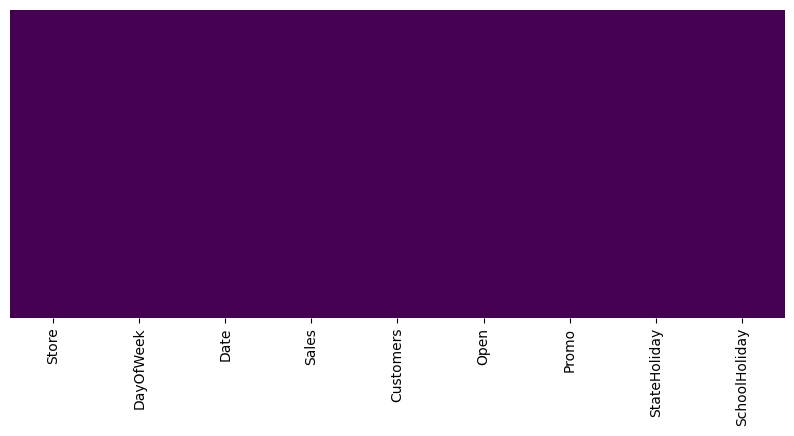

In [130]:
plt.figure(figsize=(10,4))
sns.heatmap(sales_df.isnull(),yticklabels=False, cbar=False,cmap='viridis')

In [131]:
sales_df.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

* Average 600 customers per day, maximum is 4500 (note that we can't see the outlier at 7388!)
* Data is equally distibuted across various Days of the week (~150000 observations x 7 day = ~1.1 million observation)
* Stores are open ~80% of the time
* Data is equally distributed among all stores (no bias)
* Promo #1 was running ~40% of the time
* Average sales around 5000-6000 Euros
* School holidays are around ~18% of the time

array([[<Axes: title={'center': 'Store'}>,
        <Axes: title={'center': 'DayOfWeek'}>,
        <Axes: title={'center': 'Sales'}>],
       [<Axes: title={'center': 'Customers'}>,
        <Axes: title={'center': 'Open'}>,
        <Axes: title={'center': 'Promo'}>],
       [<Axes: title={'center': 'SchoolHoliday'}>, <Axes: >, <Axes: >]],
      dtype=object)

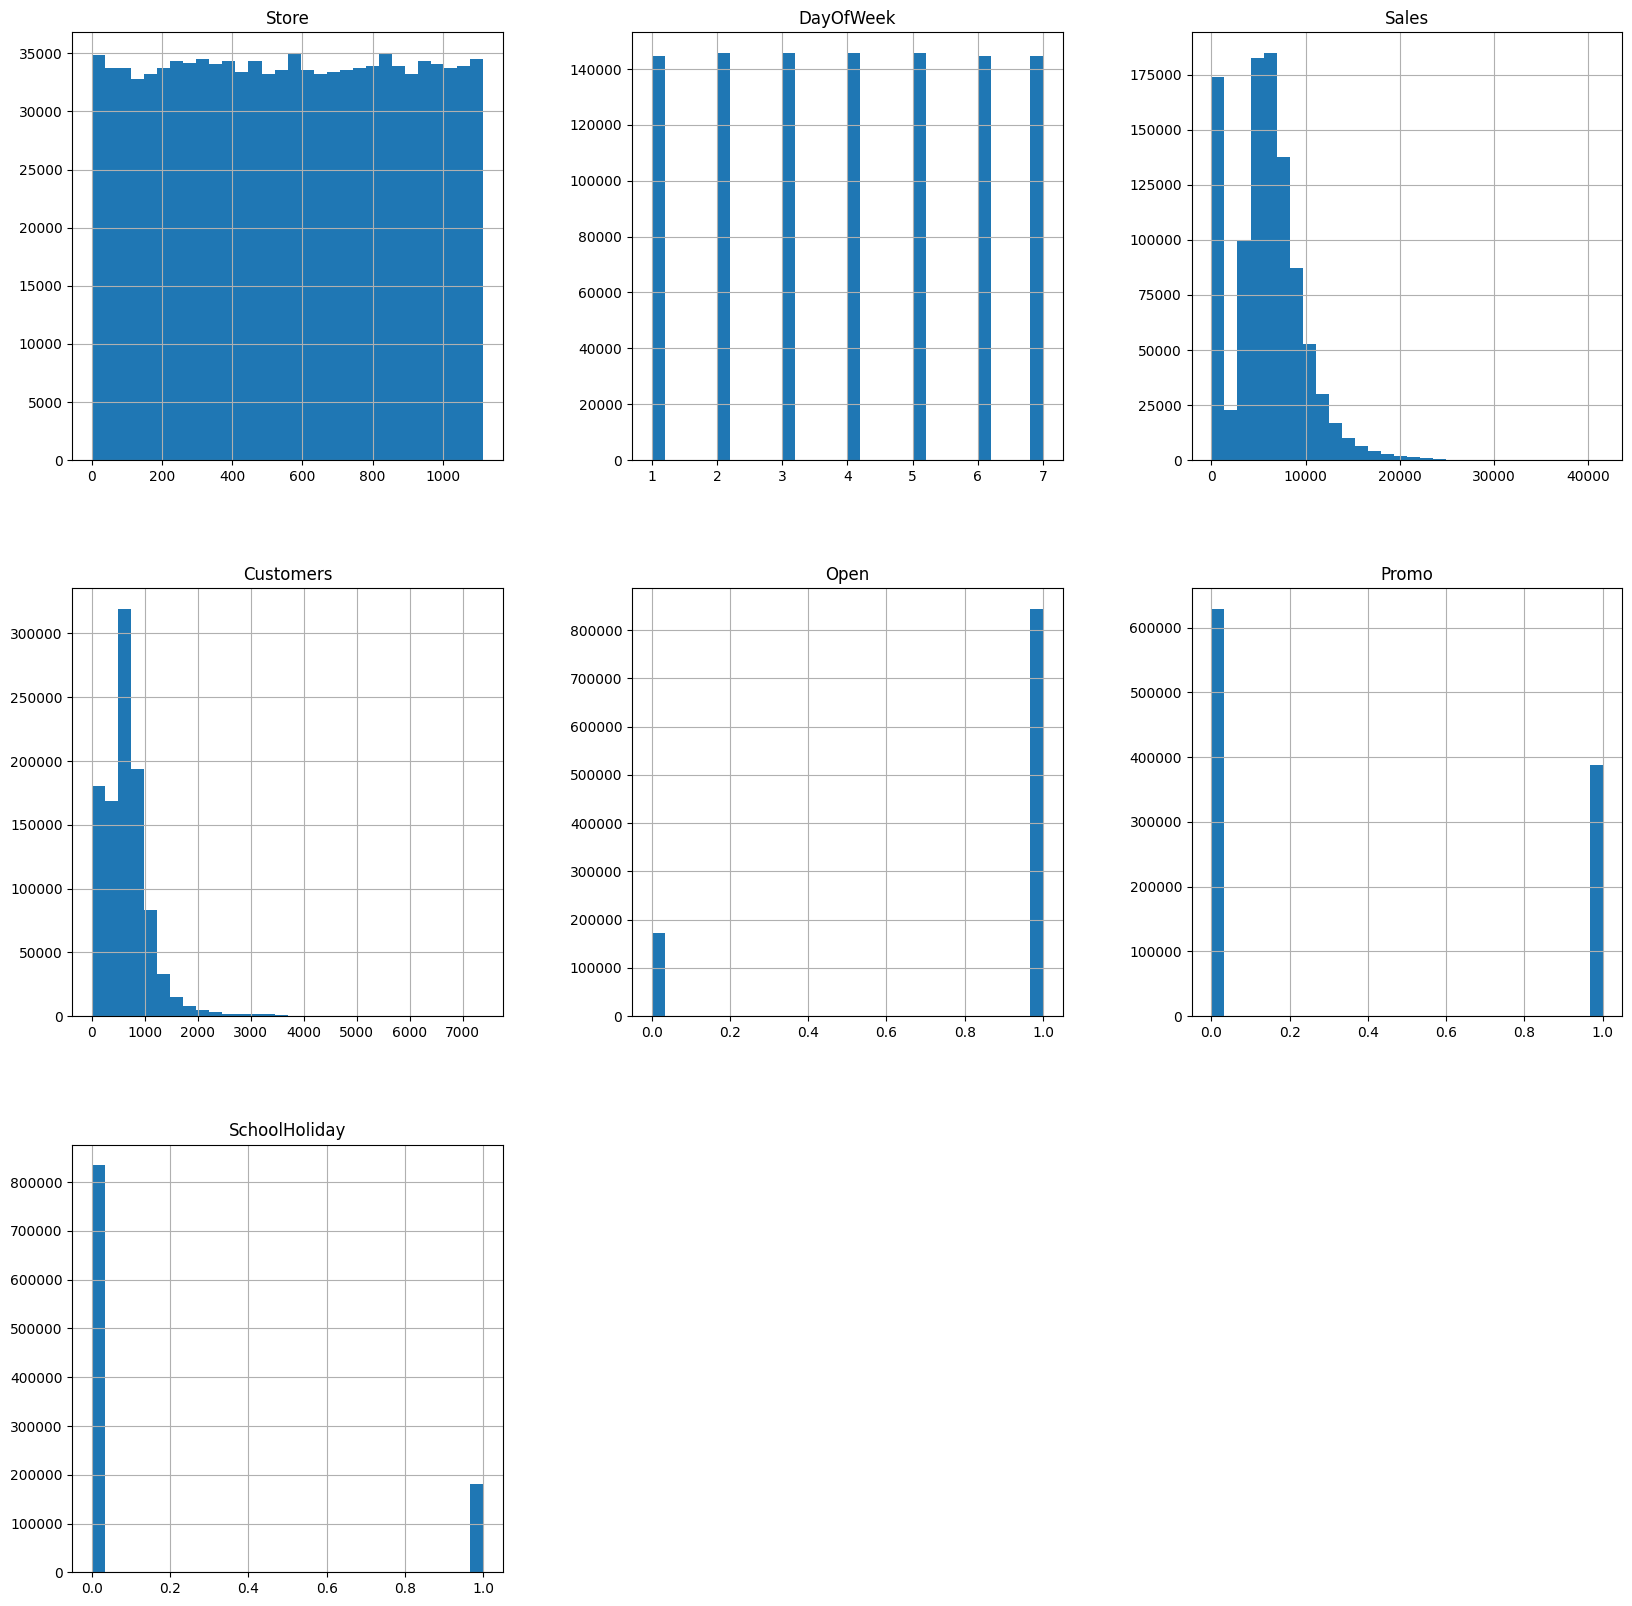

In [132]:
sales_df.hist(figsize=(20,20), bins=30)

checking the max value in Customer column

In [133]:
sales_df['Customers'].max()

np.int64(7388)

Let's see how many stores are open and closed!

In [134]:
closed_sales_df = sales_df[sales_df['Open'] == 0]
open_sales_df = sales_df[sales_df['Open'] == 1]

Count the number of stores that are open and closed

In [135]:
print('Total =', len(sales_df))
print('Closed =', len(closed_sales_df))
print('Open =', len(open_sales_df))

Total = 1017209
Closed = 172817
Open = 844392


only keep open stores and remove closed stores

In [136]:
sales_df = sales_df[sales_df['Open'] == 1]

In [137]:
sales_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,1,0,a,1
1016827,733,2,2013-01-01,10765,2377,1,0,a,1
1016863,769,2,2013-01-01,5035,1248,1,0,a,1
1017042,948,2,2013-01-01,4491,1039,1,0,a,1


Let's drop the open column since it has no meaning now

In [138]:
sales_df.drop(['Open'], axis=1, inplace=True)

In [139]:
sales_df

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,0,1
1,2,5,2015-07-31,6064,625,1,0,1
2,3,5,2015-07-31,8314,821,1,0,1
3,4,5,2015-07-31,13995,1498,1,0,1
4,5,5,2015-07-31,4822,559,1,0,1
...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,0,a,1
1016827,733,2,2013-01-01,10765,2377,0,a,1
1016863,769,2,2013-01-01,5035,1248,0,a,1
1017042,948,2,2013-01-01,4491,1039,0,a,1


Average sales = 6955 Euros,	average number of customers = 762	(went up)

In [140]:
sales_df.describe()

,Store,DayOfWeek,Sales,Customers,Promo,SchoolHoliday
count,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000
mean,558.422920,3.520361,6955.514291,762.728395,0.446352,0.193580
std,321.731914,1.723689,3104.214680,401.227674,0.497114,0.395103
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,280.000000,2.000000,4859.000000,519.000000,0.000000,0.000000
50%,558.000000,3.000000,6369.000000,676.000000,0.000000,0.000000
75%,837.000000,5.000000,8360.000000,893.000000,1.000000,0.000000
max,1115.000000,7.000000,41551.000000,7388.000000,1.000000,1.000000


### TASK #3.2: EXPLORE STORES INFORMATION DATA

Let's see if we have any missing data in the store information dataframe!

<Axes: >

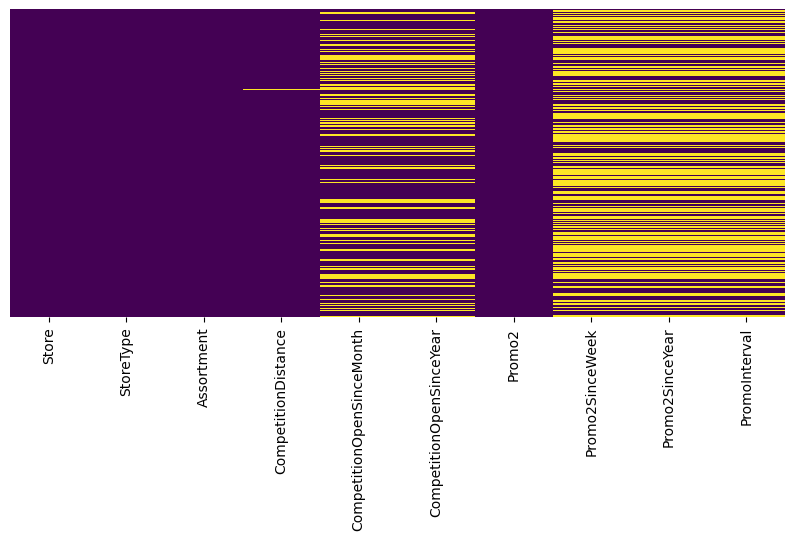

In [141]:
plt.figure(figsize=(10,4))
sns.heatmap(store_df.isnull(),yticklabels=False, cbar=False,cmap='viridis')

In [142]:
store_df.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [143]:
store_df[store_df['Promo2'] == 0]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
5,6,a,a,310.0,12.0,2013.0,0,NaN,NaN,NaN
6,7,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1107,1108,a,a,540.0,4.0,2004.0,0,NaN,NaN,NaN
1109,1110,c,c,900.0,9.0,2010.0,0,NaN,NaN,NaN
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN


* It seems like if 'promo2' is zero, 'Promo2SinceWeek', 'Promo2SinceYear', and 'PromoInterval' information is set to zero
* There are 354 rows where 'CompetitionOpenSinceYear' and 'CompetitionOpenSinceMonth' is missing
* Let's set these values to zeros

In [144]:
str_cols = ['Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth']

In [145]:
store_df[str_cols] = store_df[str_cols].apply(lambda x: x.fillna(0))
# or 
# for str in str_cols:
    # store_df[str].fillna(0, inplace=True)

let's check the heatmap again for the missing values

<Axes: >

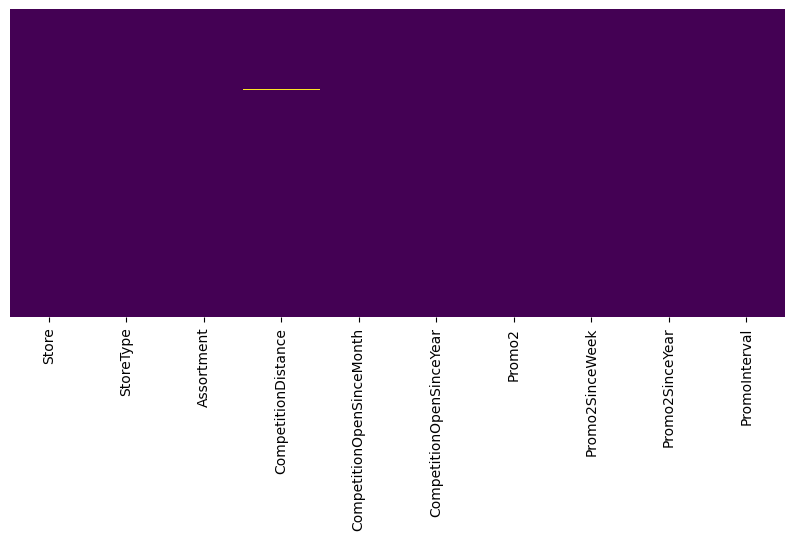

In [146]:
plt.figure(figsize=(10,4))
sns.heatmap(store_df.isnull(),yticklabels=False, cbar=False,cmap='viridis')

There are 3 rows with 'competitionDistance' values missing, let's fill them up with with average values of the 'CompetitionDistance' column

In [147]:
store_df['CompetitionDistance'].fillna(store_df['CompetitionDistance'].mean(), inplace=True)

In [148]:
store_df.isnull().sum()

Store                        0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

* half of stores are involved in promo 2
* half of the stores have their competition at a distance of 0-3000m (3 kms away)

array([[<Axes: title={'center': 'Store'}>,
        <Axes: title={'center': 'CompetitionDistance'}>,
        <Axes: title={'center': 'CompetitionOpenSinceMonth'}>],
       [<Axes: title={'center': 'CompetitionOpenSinceYear'}>,
        <Axes: title={'center': 'Promo2'}>,
        <Axes: title={'center': 'Promo2SinceWeek'}>],
       [<Axes: title={'center': 'Promo2SinceYear'}>, <Axes: >, <Axes: >]],
      dtype=object)

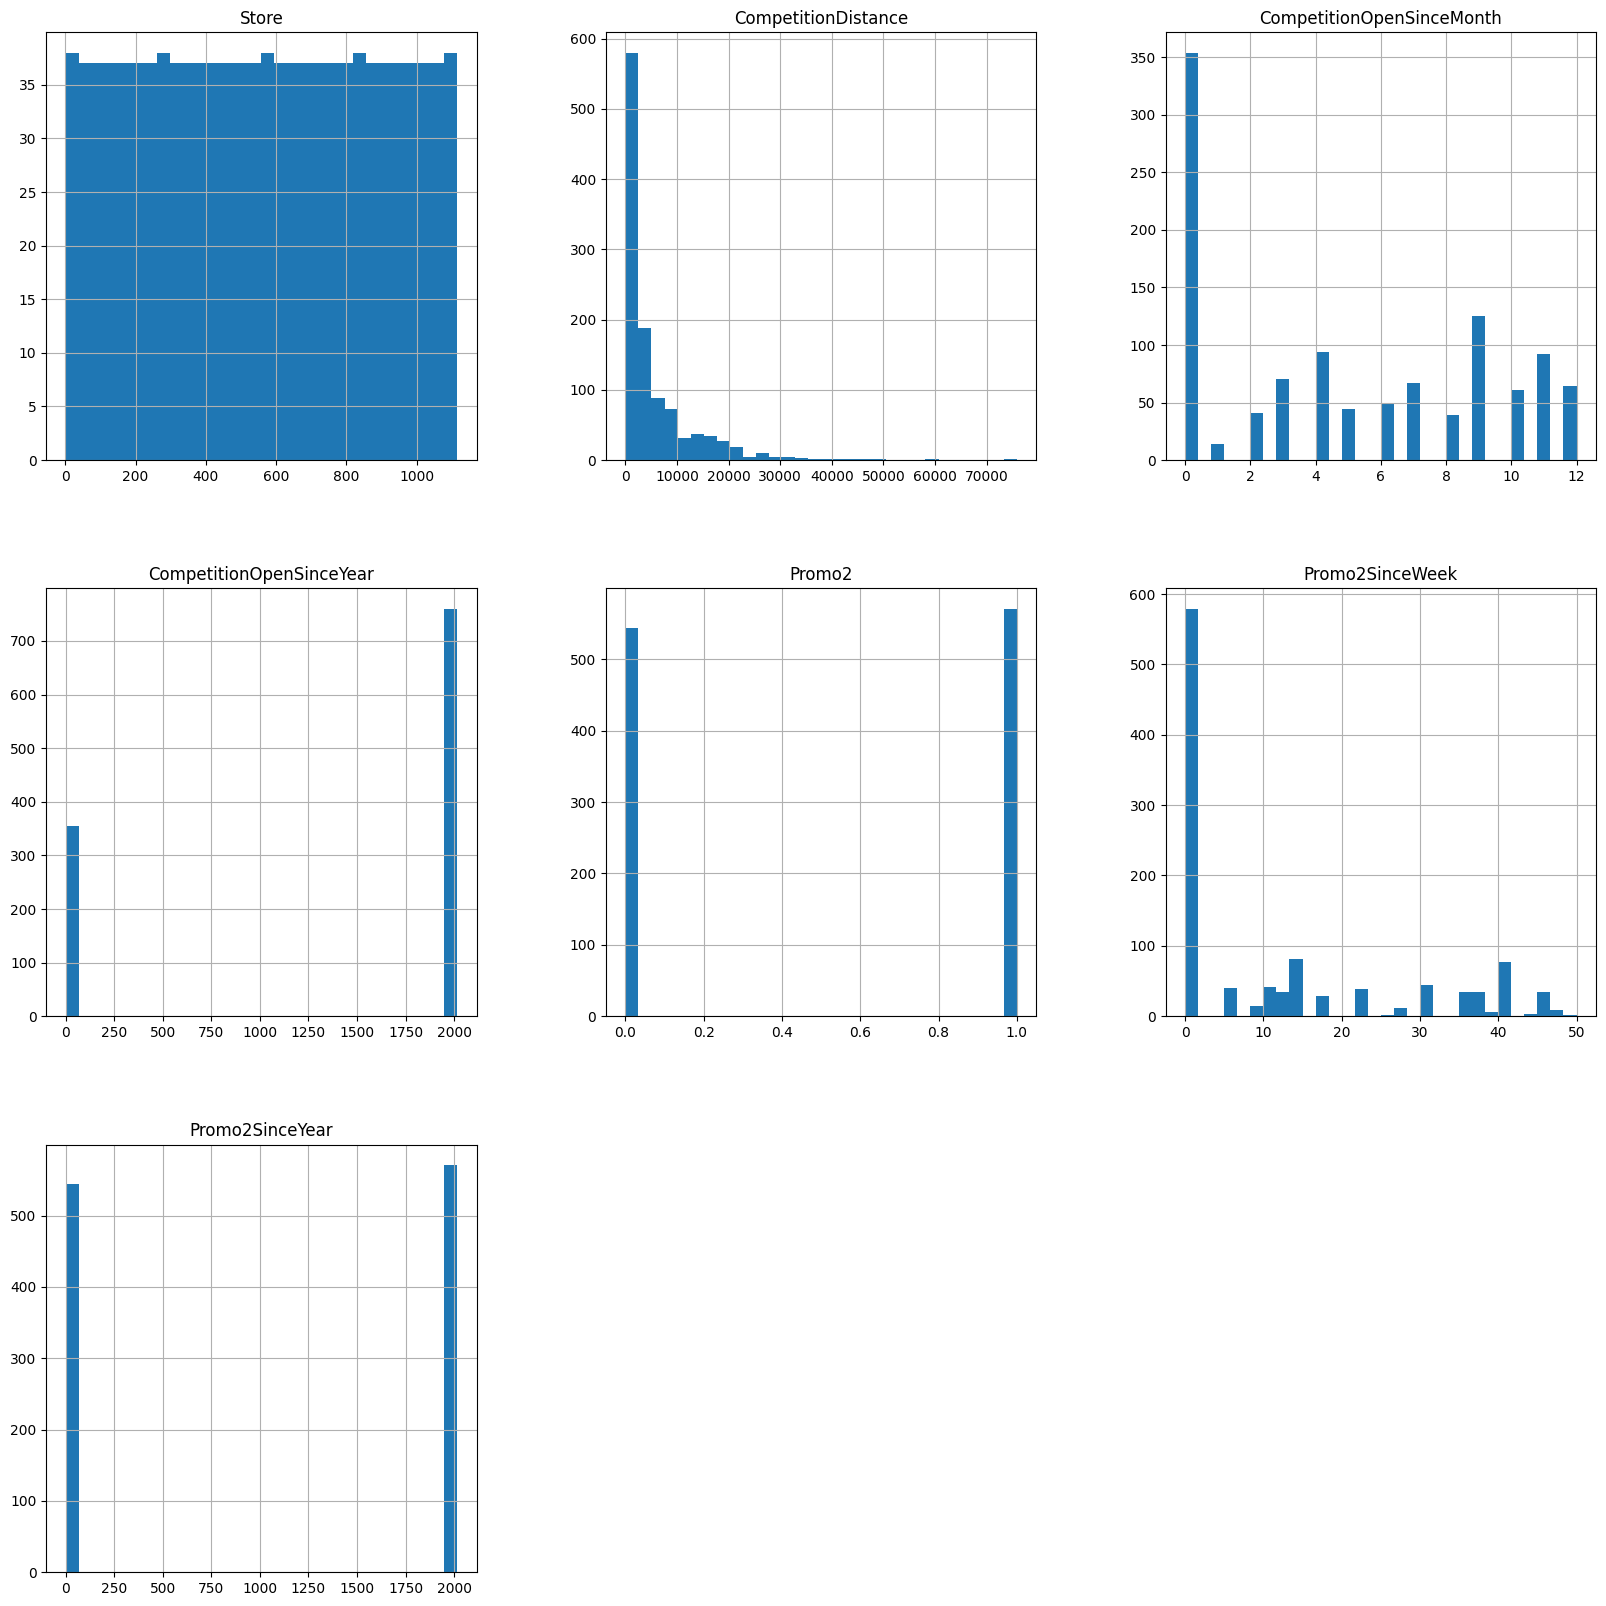

In [149]:
store_df.hist(figsize=(20,20), bins=30)

conclusion-       half of stores are involved in promo 2 and  half of the stores have their competition at a distance of 0-3000m (3 kms away)

### TASK #3.3: EXPLORE MERGED DATASET

Let's merge both data frames together based on 'store'

In [150]:
sales_all_df = pd.merge(sales_df, store_df, how='inner', on='Store')
sales_all_df

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,2,5,2015-07-31,6064,625,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,0
4,5,5,2015-07-31,4822,559,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
844387,682,2,2013-01-01,3375,566,0,a,1,b,a,150.0,9.0,2006.0,0,0.0,0.0,0
844388,733,2,2013-01-01,10765,2377,0,a,1,b,b,860.0,10.0,1999.0,0,0.0,0.0,0
844389,769,2,2013-01-01,5035,1248,0,a,1,b,b,840.0,0.0,0.0,1,48.0,2012.0,"Jan,Apr,Jul,Oct"
844390,948,2,2013-01-01,4491,1039,0,a,1,b,b,1430.0,0.0,0.0,0,0.0,0.0,0


<Axes: >

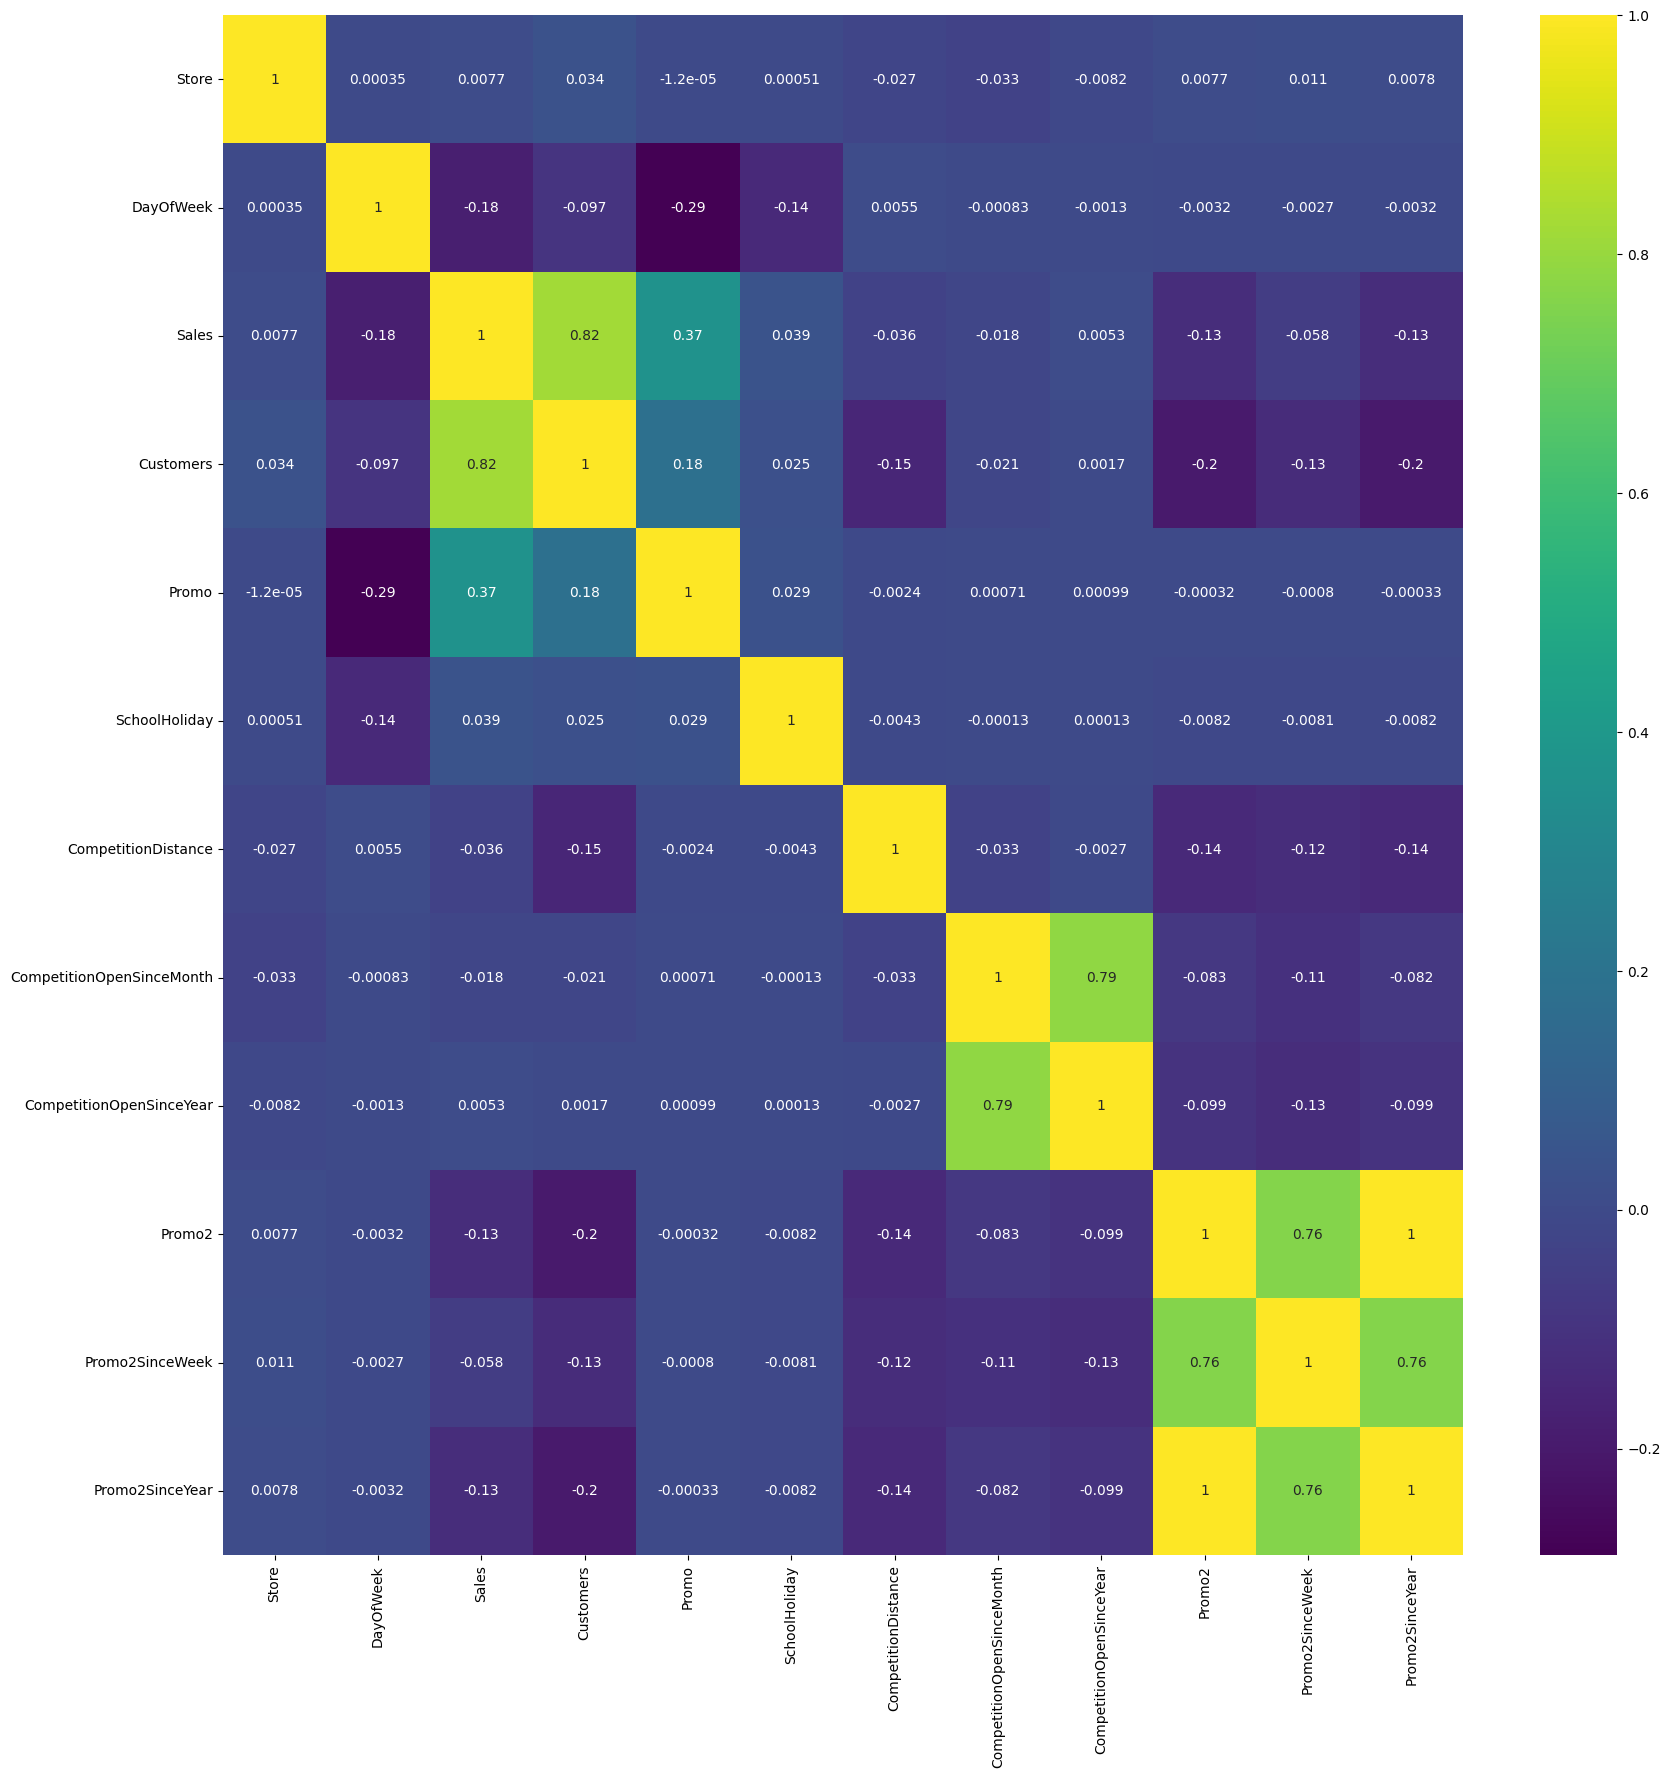

In [151]:
correlations= sales_all_df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(20,20))
sns.heatmap(correlations, annot=True, cmap='viridis')
# Customers/Prmo2 and sales are strongly correlated
# Promo2 does not seem to be effective at all

Let's separate the year, month, day and put it into a separate column

In [152]:
sales_all_df['Year'] = pd.DatetimeIndex(sales_all_df['Date']).year
sales_all_df['Month'] = pd.DatetimeIndex(sales_all_df['Date']).month
sales_all_df['Day'] = pd.DatetimeIndex(sales_all_df['Date']).day

In [153]:
sales_all_df

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015,7,31
1,2,5,2015-07-31,6064,625,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31
2,3,5,2015-07-31,8314,821,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31
3,4,5,2015-07-31,13995,1498,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,0,2015,7,31
4,5,5,2015-07-31,4822,559,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0,2015,7,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
844387,682,2,2013-01-01,3375,566,0,a,1,b,a,150.0,9.0,2006.0,0,0.0,0.0,0,2013,1,1
844388,733,2,2013-01-01,10765,2377,0,a,1,b,b,860.0,10.0,1999.0,0,0.0,0.0,0,2013,1,1
844389,769,2,2013-01-01,5035,1248,0,a,1,b,b,840.0,0.0,0.0,1,48.0,2012.0,"Jan,Apr,Jul,Oct",2013,1,1
844390,948,2,2013-01-01,4491,1039,0,a,1,b,b,1430.0,0.0,0.0,0,0.0,0.0,0,2013,1,1


lets calculate 'Average Customers Per Month'

Text(0.5, 1.0, 'Average Customers Per Month')

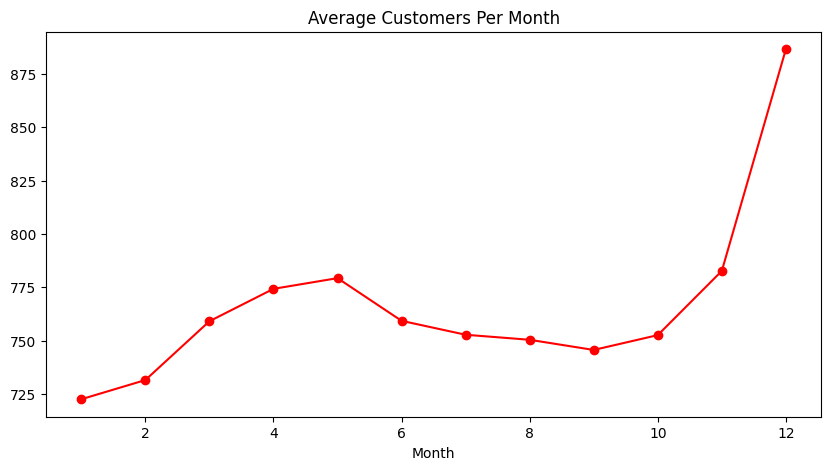

In [154]:
sales_all_df.groupby('Month')['Customers'].mean().plot(figsize=(10,5), marker='o', color='r')
plt.title('Average Customers Per Month')

lets calculate 'Average Sales Per Month'

Text(0.5, 1.0, 'Average sales Per Month')

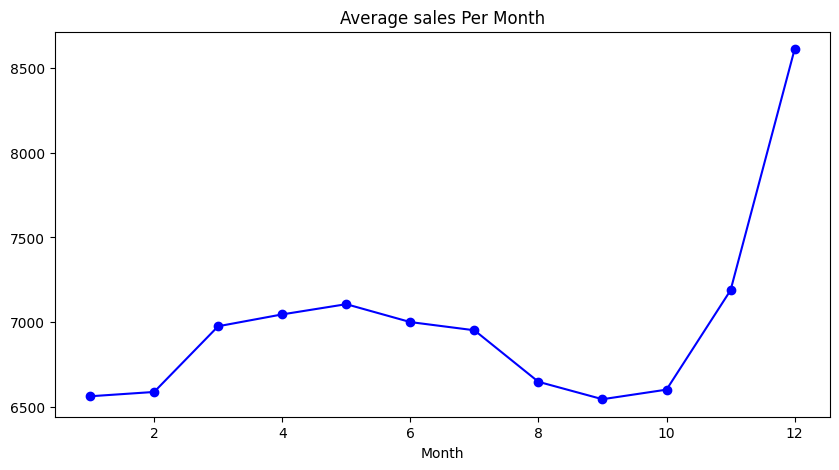

In [155]:
sales_all_df.groupby('Month')['Sales'].mean().plot(figsize=(10,5), marker='o', color='b')
plt.title('Average sales Per Month')

Lets calculate 'Average Customers Per Day'

Text(0.5, 1.0, 'Average Customers Per Day')

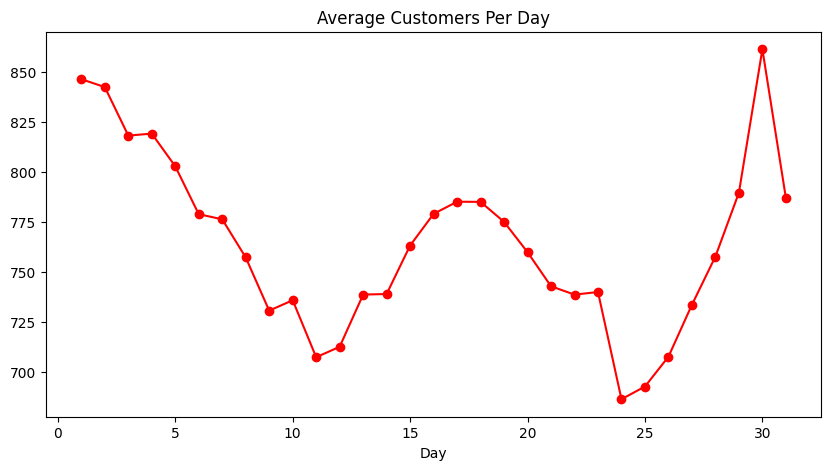

In [156]:
sales_all_df.groupby('Day')['Customers'].mean().plot(figsize=(10,5), marker='o', color='r')
plt.title('Average Customers Per Day')

Lets calculate 'Average Sales Per Day'

Text(0.5, 1.0, 'Average Sales Per Day')

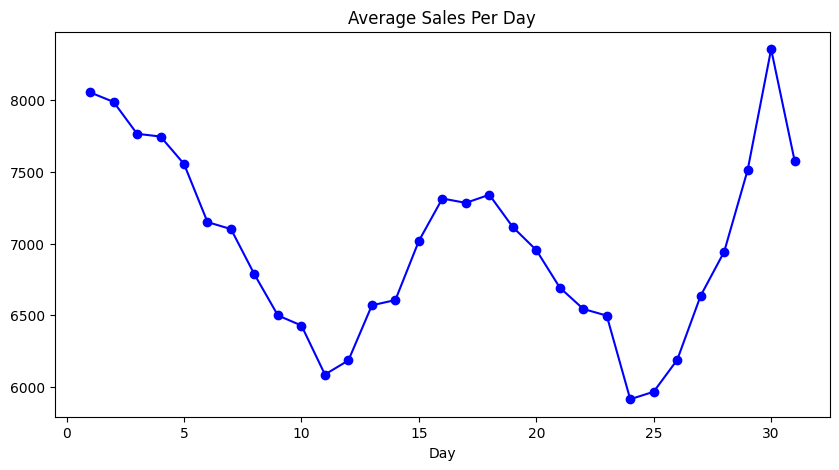

In [157]:
sales_all_df.groupby('Day')['Sales'].mean().plot(figsize=(10,5), marker='o', color='b')
plt.title('Average Sales Per Day')

Lets calculate 'Average Customers Per Day Of Week'

Text(0.5, 1.0, 'Average Customers Per Day Of Week')

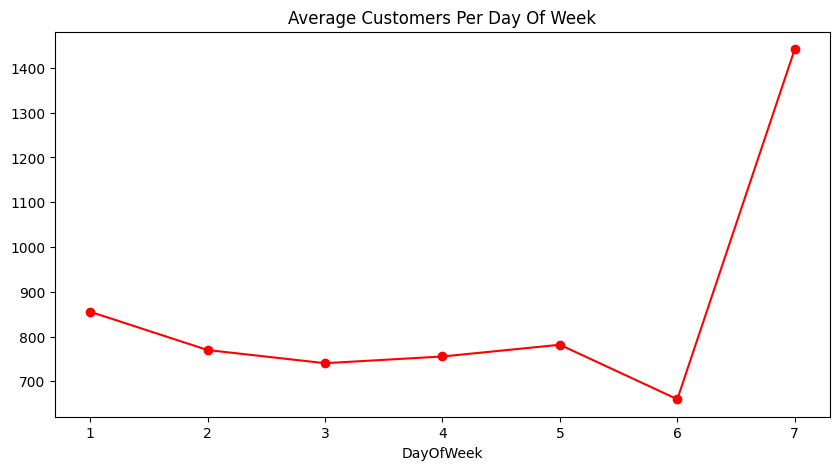

In [158]:
sales_all_df.groupby('DayOfWeek')['Customers'].mean().plot(figsize=(10,5), marker='o', color='r')
plt.title('Average Customers Per Day Of Week')

Lets calculate 'Average Sales Per Day Of Week'

Text(0.5, 1.0, 'Average Sales Per Day Of Week')

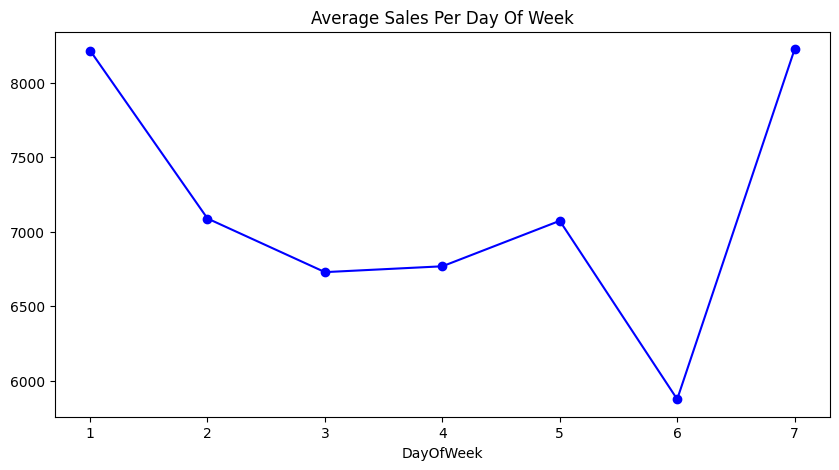

In [159]:
sales_all_df.groupby('DayOfWeek')['Sales'].mean().plot(figsize=(10,5), marker='o', color='b')
plt.title('Average Sales Per Day Of Week')

In [160]:
# fig, ax = plt.subplots(figsize = (20, 10))
# sales_all_df.groupby(['Date', 'StoreType']).mean()['Sales'].unstack().plot(ax=ax)

# Above code is not working because of unstack() method but groupby() is working so we are using pivot_table() method and it is working fine below

<Axes: xlabel='Date'>

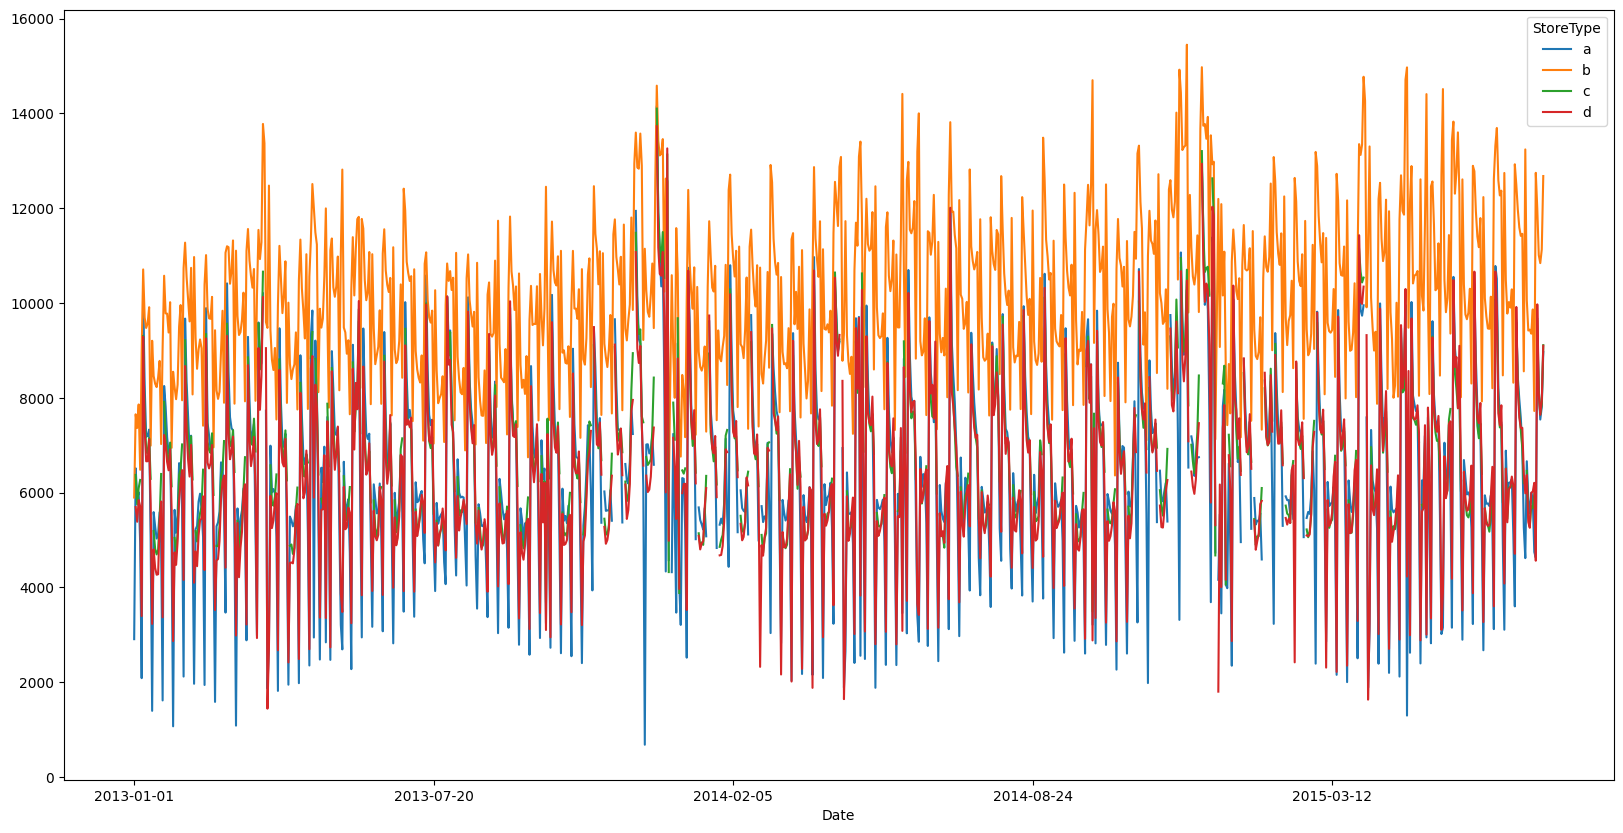

In [161]:
fig, ax = plt.subplots(figsize=(20, 10))
sales_all_df.pivot_table(values='Sales', index='Date', columns='StoreType', aggfunc='mean').plot(ax=ax)

<Axes: xlabel='Promo', ylabel='Customers'>

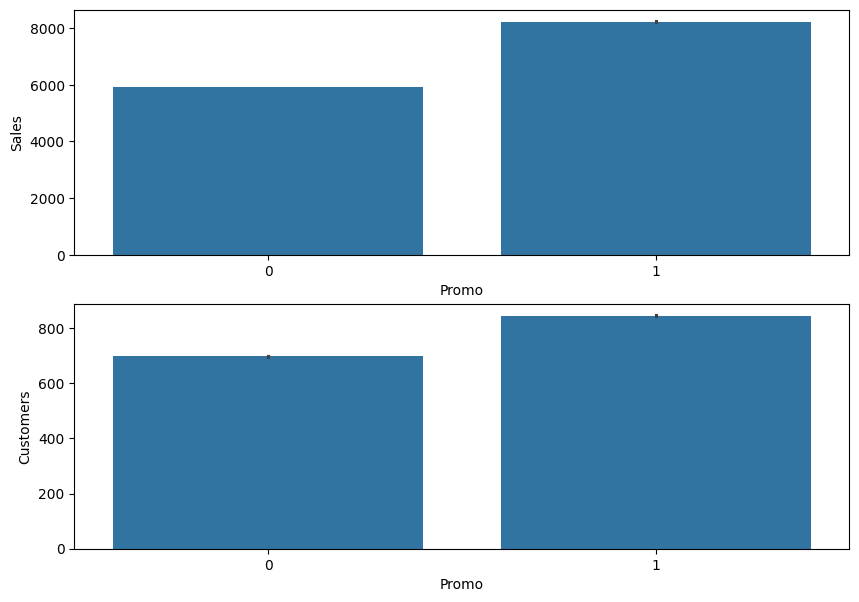

In [162]:
plt.figure(figsize=(10,7))

plt.subplot(211)
sns.barplot(x='Promo', y='Sales', data=sales_all_df)

plt.subplot(212)
sns.barplot(x='Promo', y='Customers', data=sales_all_df)

## TASK #4: TRAIN THE MODEL PART A

In [163]:
from prophet import Prophet

In [164]:
def sales_predictions(Store_ID, sales_df, periods):
    sales_df = sales_df[sales_df['Store'] == Store_ID]
    sales_df = sales_df[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})
    
    model = Prophet()
    model.fit(sales_df)
    future = model.make_future_dataframe(periods=periods)
    forecast = model.predict(future)

    figure = model.plot(forecast, xlabel = 'Date', ylabel = 'Sales')
    figure2 = model.plot_components(forecast)



16:04:26 - cmdstanpy - INFO - Chain [1] start processing
16:04:26 - cmdstanpy - INFO - Chain [1] done processing


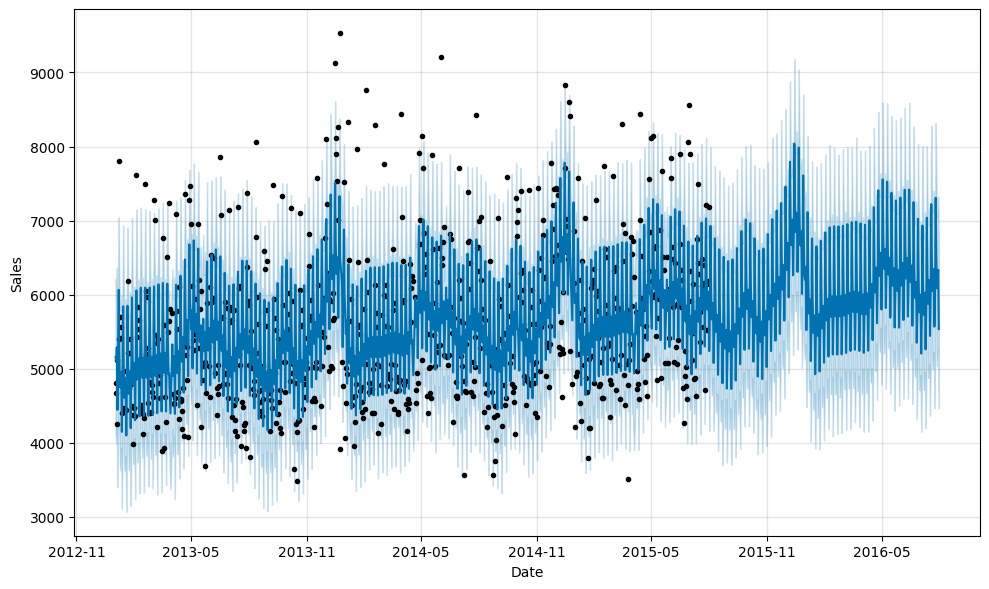

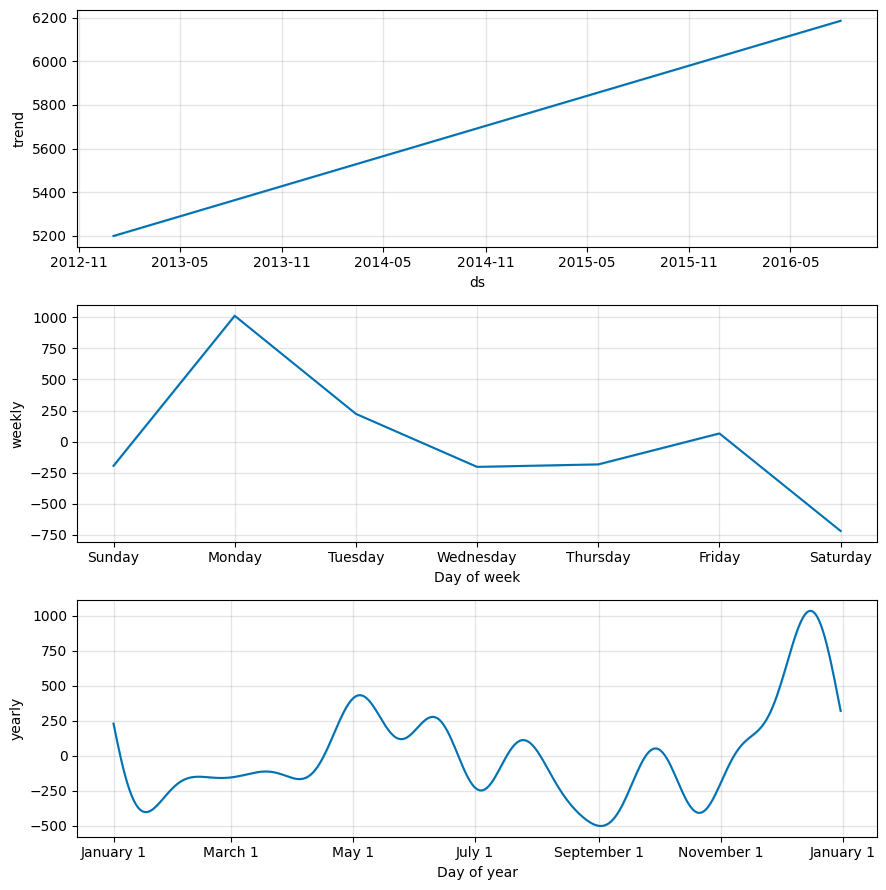

In [165]:
sales_predictions(10, sales_all_df, 365)

## TASK #5: TRAIN THE MODEL PART B

* StateHoliday: indicates a state holiday. Normally all stores, with few exceptions, are closed on state holidays. Note that all schools are closed on public holidays and weekends. a = public holiday, b = Easter holiday, c = Christmas, 0 = None

* SchoolHoliday: indicates if the (Store, Date) was affected by the closure of public schools

In [166]:
def sales_predictions(Store_ID, sales_df, holidays, periods):

    sales_df = sales_df[sales_df['Store'] == Store_ID]
    sales_df = sales_df[['Date', 'Sales']].rename(columns = {'Date': 'ds', 'Sales': 'y'})
    sales_df = sales_df.sort_values('ds')

    model = Prophet(holidays = holidays)
    model.fit(sales_df)
    future = model.make_future_dataframe(periods = periods)
    forecast = model.predict(future)
    figure = model.plot(forecast, xlabel='Date', ylabel='Sales')
    figure2 = model.plot_components(forecast)

Get all the dates pertaining to school holidays

In [167]:
school_holidays = sales_all_df[sales_all_df['SchoolHoliday'] == 1][['Date']].loc[:, "Date"].values

In [168]:
school_holidays.shape

(163457,)

Get all the dates pertaining to state holidays

In [169]:
state_holidays = sales_all_df[(sales_all_df['StateHoliday'] == 'a') | (sales_all_df['StateHoliday'] == 'b') | (sales_all_df['StateHoliday'] == 'c')].loc[:, 'Date'].values

In [170]:
state_holidays.shape

(910,)

In [171]:
state_holidays = pd.DataFrame({'ds': pd.to_datetime(state_holidays),
                           'holiday' : 'state_holiday'})

In [172]:
state_holidays

,ds,holiday
0,2015-06-04,state_holiday
1,2015-06-04,state_holiday
2,2015-06-04,state_holiday
3,2015-06-04,state_holiday
4,2015-06-04,state_holiday
...,...,...
905,2013-01-01,state_holiday
906,2013-01-01,state_holiday
907,2013-01-01,state_holiday
908,2013-01-01,state_holiday


In [173]:
school_holidays = pd.DataFrame({'ds' : pd.to_datetime(school_holidays),
                               'holiday': 'school_holiday'})

In [174]:
school_holidays

,ds,holiday
0,2015-07-31,school_holiday
1,2015-07-31,school_holiday
2,2015-07-31,school_holiday
3,2015-07-31,school_holiday
4,2015-07-31,school_holiday
...,...,...
163452,2013-01-01,school_holiday
163453,2013-01-01,school_holiday
163454,2013-01-01,school_holiday
163455,2013-01-01,school_holiday


* concatenate both school and state holidays

In [175]:
school_state_holidays = pd.concat((state_holidays, school_holidays))

In [176]:
school_state_holidays

,ds,holiday
0,2015-06-04,state_holiday
1,2015-06-04,state_holiday
2,2015-06-04,state_holiday
3,2015-06-04,state_holiday
4,2015-06-04,state_holiday
...,...,...
163452,2013-01-01,school_holiday
163453,2013-01-01,school_holiday
163454,2013-01-01,school_holiday
163455,2013-01-01,school_holiday


Let's make predictions using holidays for a specific store

In [ ]:
sales_predictions(6,sales_all_df,school_state_holidays ,90)

16:04:32 - cmdstanpy - INFO - Chain [1] start processing
16:04:32 - cmdstanpy - INFO - Chain [1] done processing


## EXCELLENT JOB!